# Pirates Pain Classification - Data Exploration & Visualization

This notebook explores the dataset to understand:
1. **Class distribution** - How imbalanced is the dataset?
2. **Feature distributions** - What do the sensor readings look like?
3. **Temporal patterns** - Are there time-based patterns in the data?
4. **Feature correlations** - Which features are related?
5. **Sample characteristics** - How do different pain levels differ?
6. **Sequence analysis** - How does windowing affect the data?

**Goal:** Make informed decisions about preprocessing, augmentation, and model architecture.

## 1. Setup

In [21]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import utilities
from src.utils.config import load_config
from src.utils.seed import set_seed

# Load config
config = load_config('configs/default_config.yaml', validate=True)
set_seed(config['seed'])

print("✓ Setup complete")
print(f"Config: {config['logging']['experiment_name']}")

✓ Configuration validation passed
✓ Setup complete
Config: oversampling_B_rnn


## 2. Load Raw Data

In [22]:
# Load raw data
data_config = config['data']
X_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_file']))
y_train = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['train_labels_file']))
X_test = pd.read_csv(os.path.join(data_config['raw_dir'], data_config['test_file']))

print("="*80)
print("DATA OVERVIEW")
print("="*80)
print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test data: {X_test.shape}")
print(f"\nUnique samples (users): {X_train['sample_index'].nunique()}")
print(f"Timesteps per sample: {X_train.groupby('sample_index').size().unique()}")
print(f"Features (excluding sample_index, time): {X_train.shape[1] - 2}")
print("="*80)

DATA OVERVIEW
Training data: (105760, 40)
Training labels: (661, 2)
Test data: (211840, 40)

Unique samples (users): 661
Timesteps per sample: [160]
Features (excluding sample_index, time): 38


## 3. Class Distribution Analysis

**Critical for understanding:**
- How imbalanced is the dataset?
- Do we need class weights?
- How much oversampling is needed?

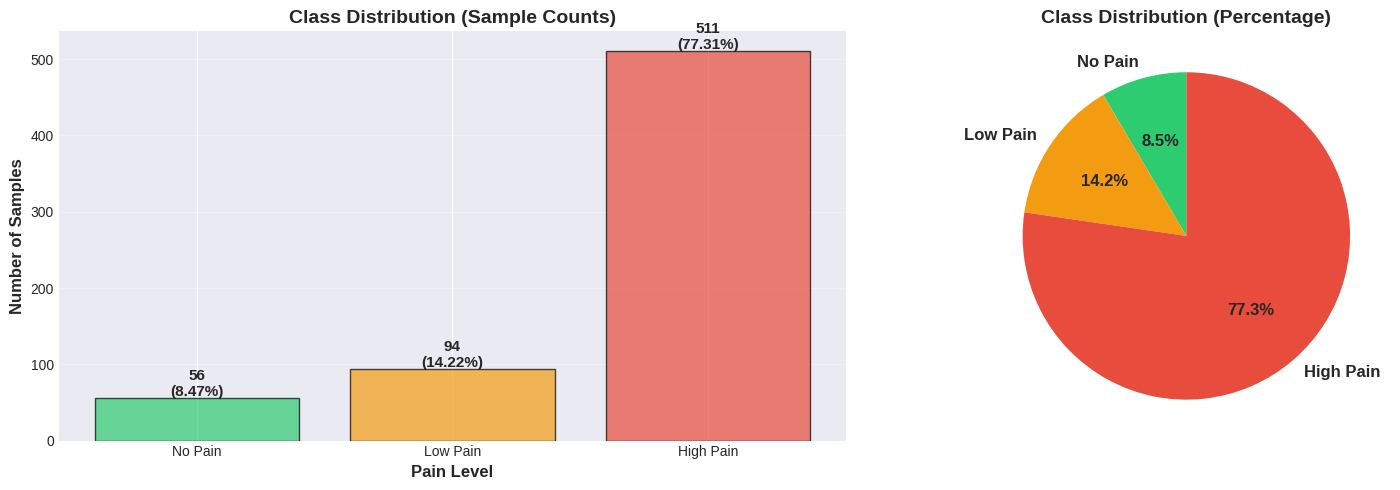


CLASS IMBALANCE ANALYSIS
Class high_pain:   56 samples ( 8.47%) - Ratio to majority: 0.11
Class low_pain:   94 samples (14.22%) - Ratio to majority: 0.18
Class no_pain:  511 samples (77.31%) - Ratio to majority: 1.00

⚠️  Imbalance ratio (max/min): 9.12x
   → RECOMMENDATION: Use class weights AND oversampling


In [23]:
# Class distribution
class_counts = y_train['label'].value_counts().sort_index()
class_percentages = (class_counts / len(y_train) * 100).round(2)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax1.bar(class_counts.index, class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Pain Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution (Sample Counts)', fontsize=14, fontweight='bold')
ax1.set_xticks(class_counts.index)
ax1.set_xticklabels(['No Pain', 'Low Pain', 'High Pain'])
ax1.grid(axis='y', alpha=0.3)

# Add count labels
for i, (idx, val) in enumerate(class_counts.items()):
    ax1.text(idx, val + 2, f'{val}\n({class_percentages[idx]}%)', 
             ha='center', fontweight='bold', fontsize=11)

# Pie chart
ax2.pie(class_counts.values, labels=['No Pain', 'Low Pain', 'High Pain'], 
        autopct='%1.1f%%', colors=colors, startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
for label, count in class_counts.items():
    ratio = count / class_counts.max()
    print(f"Class {label}: {count:4d} samples ({class_percentages[label]:5.2f}%) - Ratio to majority: {ratio:.2f}")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚠️  Imbalance ratio (max/min): {imbalance_ratio:.2f}x")
if imbalance_ratio > 2:
    print("   → RECOMMENDATION: Use class weights AND oversampling")
elif imbalance_ratio > 1.5:
    print("   → RECOMMENDATION: Use class weights")
else:
    print("   → Dataset is relatively balanced")
print("="*80)

## 4. Feature Distribution Analysis

**What to look for:**
- Outliers (extreme values)
- Skewness (need log transform?)
- Constant features (can be dropped)
- Scale differences (need normalization?)

In [24]:
# Get feature columns (exclude metadata)
feature_cols = [col for col in X_train.columns if col not in ['sample_index', 'time']]

# Select only numeric columns for statistical analysis
numeric_cols = X_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [col for col in feature_cols if col not in numeric_cols]

if non_numeric_cols:
    print(f"⚠️  Found {len(non_numeric_cols)} non-numeric features: {non_numeric_cols}")
    print("   These will be excluded from numerical statistics\n")

# Calculate statistics on numeric features only
feature_stats = X_train[numeric_cols].describe().T
feature_stats['skewness'] = X_train[numeric_cols].skew()
feature_stats['is_constant'] = (feature_stats['std'] < 1e-6)

print("="*80)
print("FEATURE STATISTICS (Numeric Features Only)")
print("="*80)
print(feature_stats[['mean', 'std', 'min', 'max', 'skewness', 'is_constant']].round(3))
print("="*80)

# Identify problematic features
constant_features = feature_stats[feature_stats['is_constant']].index.tolist()
skewed_features = feature_stats[abs(feature_stats['skewness']) > 5].index.tolist()

print(f"\n⚠️  Constant features (std < 1e-6): {len(constant_features)}")
if constant_features:
    print(f"   → {constant_features}")
    print("   → RECOMMENDATION: Drop these features")

print(f"\n⚠️  Highly skewed features (|skew| > 5): {len(skewed_features)}")
if skewed_features:
    print(f"   → {skewed_features[:5]}..." if len(skewed_features) > 5 else f"   → {skewed_features}")
    print("   → RECOMMENDATION: Apply log transform or clipping")

# Update feature_cols to only include numeric features for subsequent analysis
feature_cols = numeric_cols

⚠️  Found 3 non-numeric features: ['n_legs', 'n_hands', 'n_eyes']
   These will be excluded from numerical statistics



FEATURE STATISTICS (Numeric Features Only)
                mean    std    min    max  skewness  is_constant
pain_survey_1  1.634  0.682  0.000  2.000    -1.593        False
pain_survey_2  1.655  0.670  0.000  2.000    -1.688        False
pain_survey_3  1.654  0.667  0.000  2.000    -1.678        False
pain_survey_4  1.663  0.662  0.000  2.000    -1.725        False
joint_00       0.943  0.202  0.000  1.408    -1.250        False
joint_01       0.917  0.198  0.000  1.335    -1.333        False
joint_02       0.779  0.296  0.001  1.306    -0.993        False
joint_03       0.768  0.301  0.005  1.255    -0.895        False
joint_04       0.709  0.418  0.000  1.359    -0.665        False
joint_05       0.711  0.412  0.000  1.388    -0.607        False
joint_06       0.875  0.241  0.000  1.411    -1.792        False
joint_07       0.837  0.238  0.000  1.362    -1.597        False
joint_08       0.850  0.180  0.122  1.357     0.066        False
joint_09       0.910  0.180  0.005  1.388    -0

## 5. Feature Distribution Visualization

Visualize distributions to spot outliers and patterns.

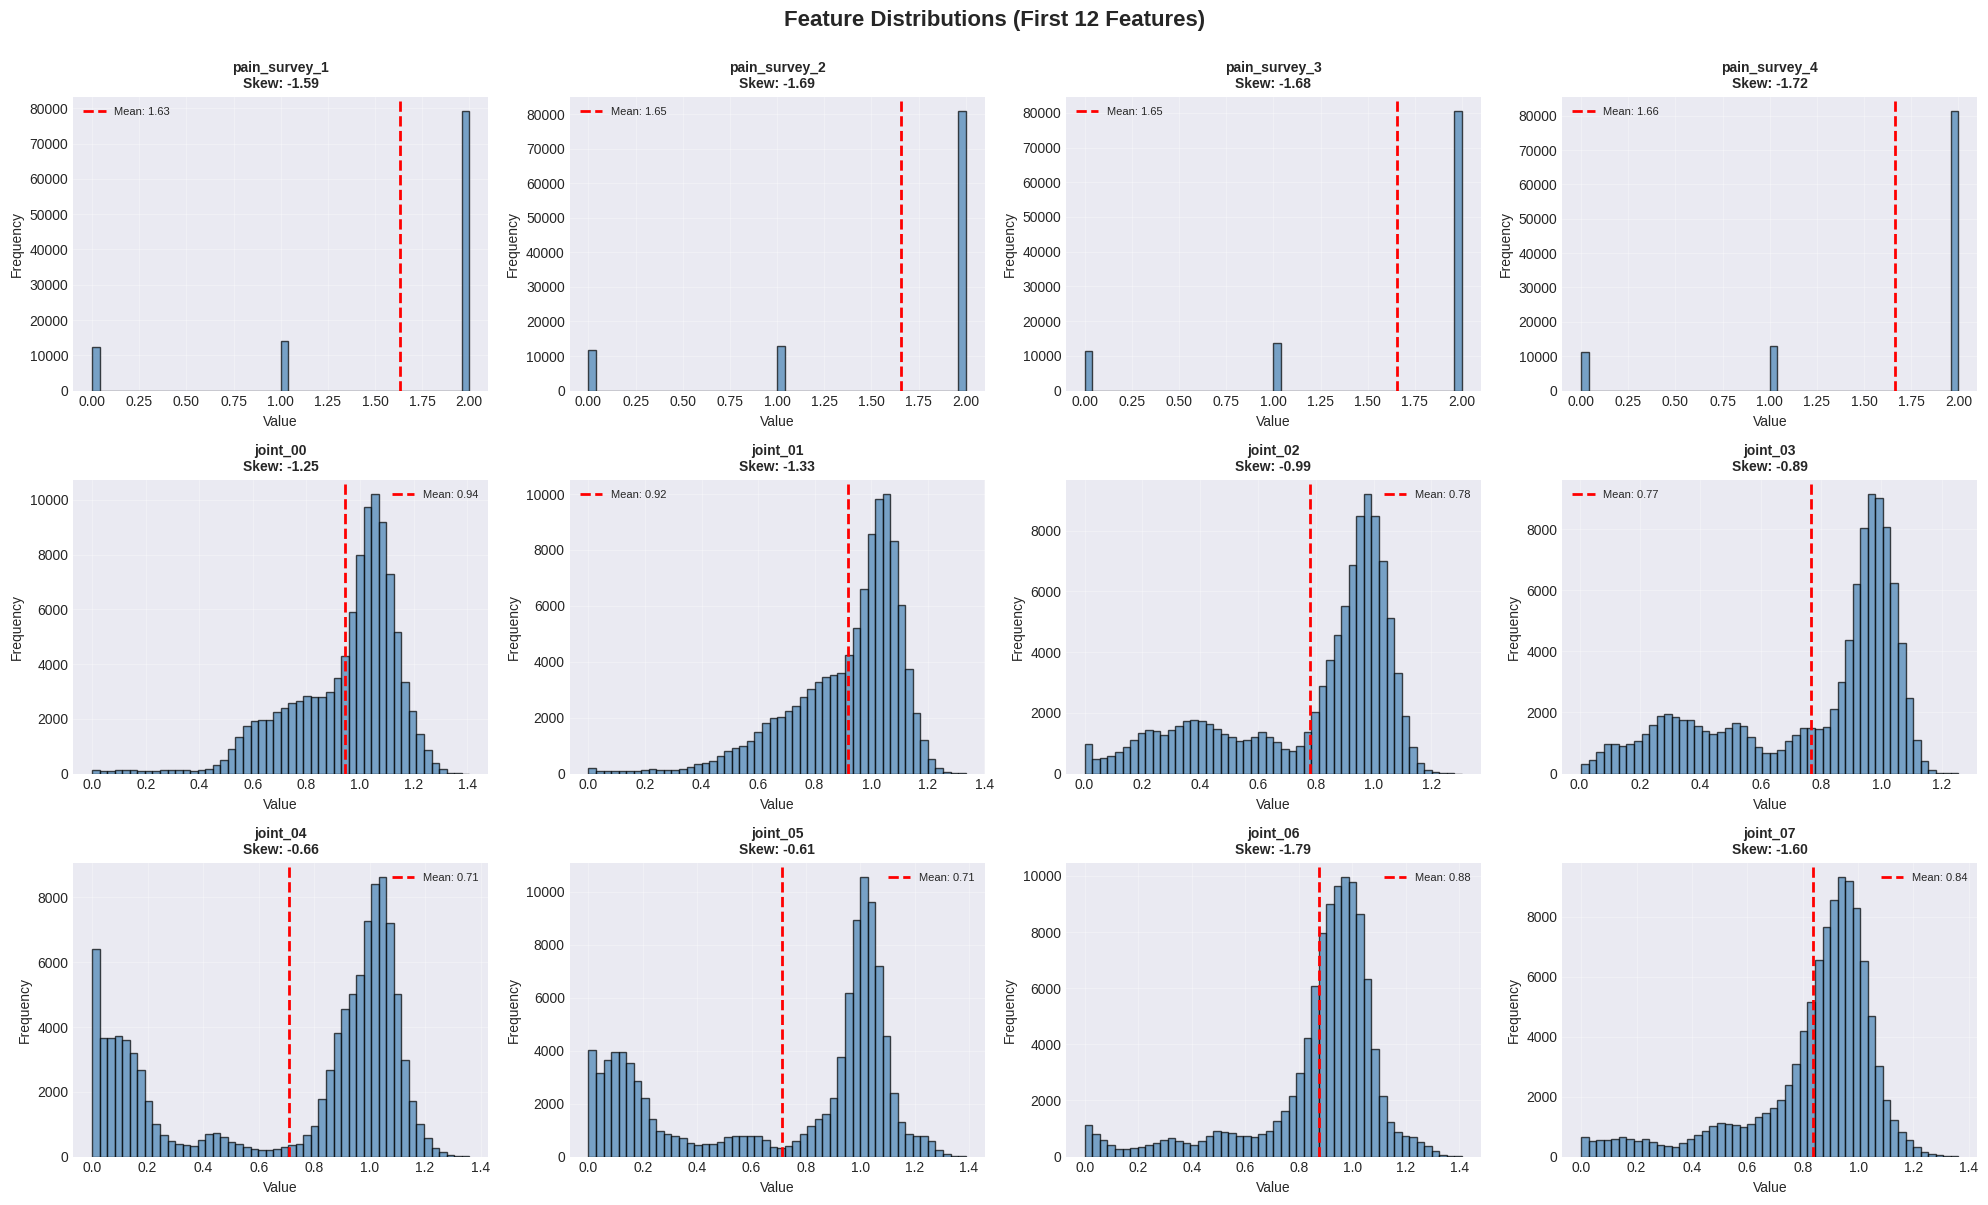

In [25]:
# Plot distributions of first 12 features
n_features_to_plot = min(12, len(feature_cols))
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols[:n_features_to_plot]):
    ax = axes[i]
    
    # Histogram
    ax.hist(X_train[col].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Statistics
    mean_val = X_train[col].mean()
    std_val = X_train[col].std()
    skew_val = X_train[col].skew()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.set_title(f'{col}\nSkew: {skew_val:.2f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions (First 12 Features)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Temporal Patterns by Pain Level

**Critical question:** Do different pain levels show different temporal patterns?

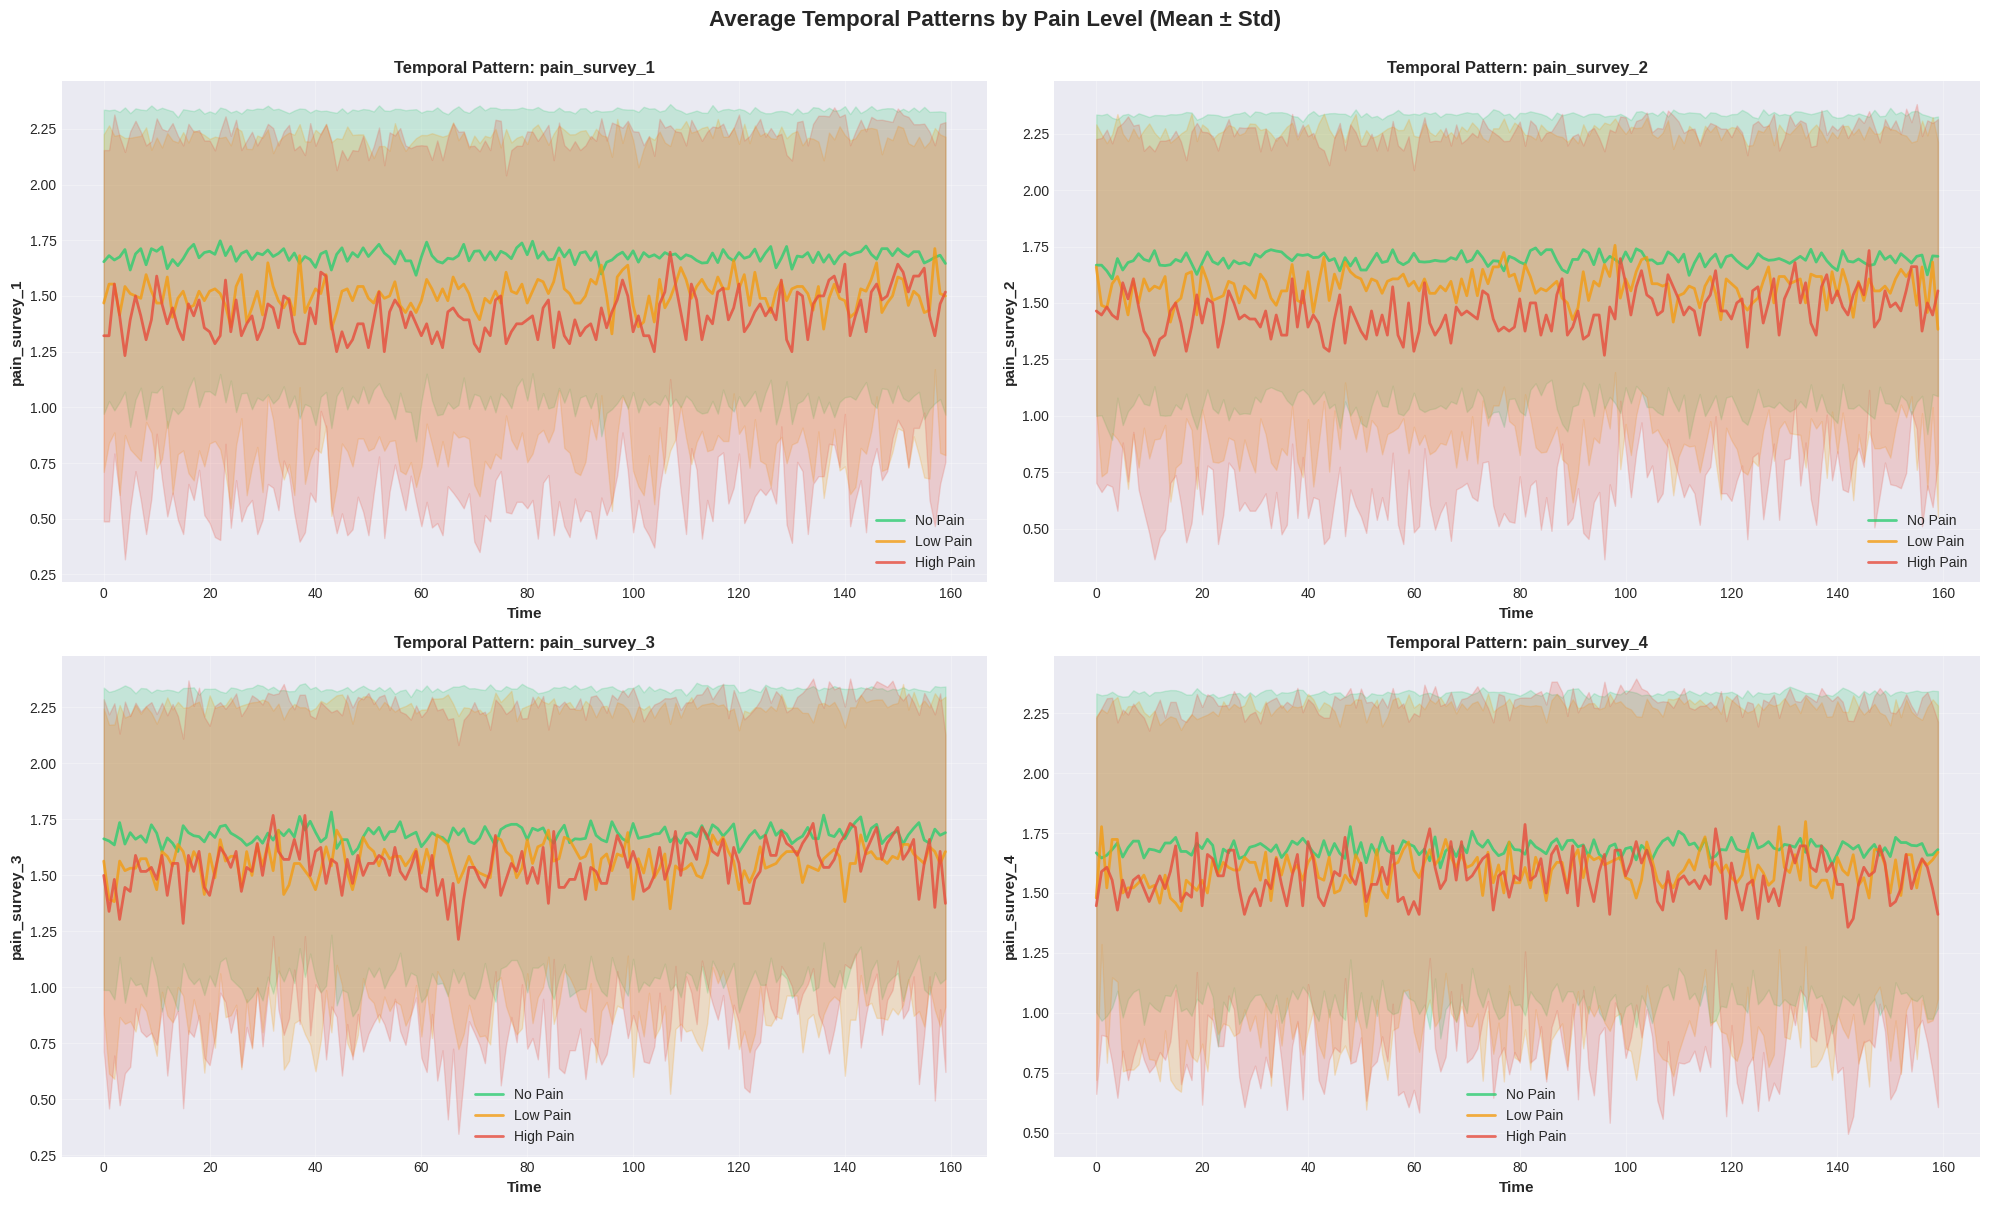


💡 ANALYSIS TIPS:
  - Look for SEPARATION between pain levels (good!)
  - Check if patterns are CONSISTENT over time
  - Wide confidence bands = high variance within class
  - If overlap is high, that feature may not be discriminative


In [26]:
# Merge data with labels
df_merged = pd.merge(X_train, y_train, on='sample_index')

# Select a few representative features to visualize
features_to_plot = feature_cols[:4]  # First 4 features

# Create label mapping based on what's in the data
unique_labels = sorted(df_merged['label'].unique())
if isinstance(unique_labels[0], str):
    # String labels like 'no_pain', 'low_pain', 'high_pain'
    label_to_int = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
    pain_labels = {0: 'No Pain', 1: 'Low Pain', 2: 'High Pain'}
    colors_pain = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
    # Convert string labels to integers for consistent plotting
    df_merged['label_int'] = df_merged['label'].map(label_to_int)
    label_col = 'label_int'
else:
    # Integer labels 0, 1, 2
    pain_labels = {0: 'No Pain', 1: 'Low Pain', 2: 'High Pain'}
    colors_pain = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
    label_col = 'label'

# Plot temporal patterns for each pain level
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    # Plot average time series for each class
    for pain_level in sorted(df_merged[label_col].unique()):
        # Get all samples for this pain level
        pain_data = df_merged[df_merged[label_col] == pain_level]
        
        # Group by time and calculate mean
        time_series = pain_data.groupby('time')[feature].agg(['mean', 'std'])
        
        # Plot mean line
        ax.plot(time_series.index, time_series['mean'], 
               label=pain_labels[pain_level], 
               color=colors_pain[pain_level],
               linewidth=2, alpha=0.8)
        
        # Plot confidence interval
        ax.fill_between(time_series.index, 
                        time_series['mean'] - time_series['std'],
                        time_series['mean'] + time_series['std'],
                        color=colors_pain[pain_level], alpha=0.2)
    
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax.set_ylabel(feature, fontsize=11, fontweight='bold')
    ax.set_title(f'Temporal Pattern: {feature}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Average Temporal Patterns by Pain Level (Mean ± Std)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n💡 ANALYSIS TIPS:")
print("  - Look for SEPARATION between pain levels (good!)")
print("  - Check if patterns are CONSISTENT over time")
print("  - Wide confidence bands = high variance within class")
print("  - If overlap is high, that feature may not be discriminative")

## 7. Feature Correlation Analysis

**Why this matters:**
- Highly correlated features can be combined or one can be dropped
- Reduces model complexity
- Can improve generalization

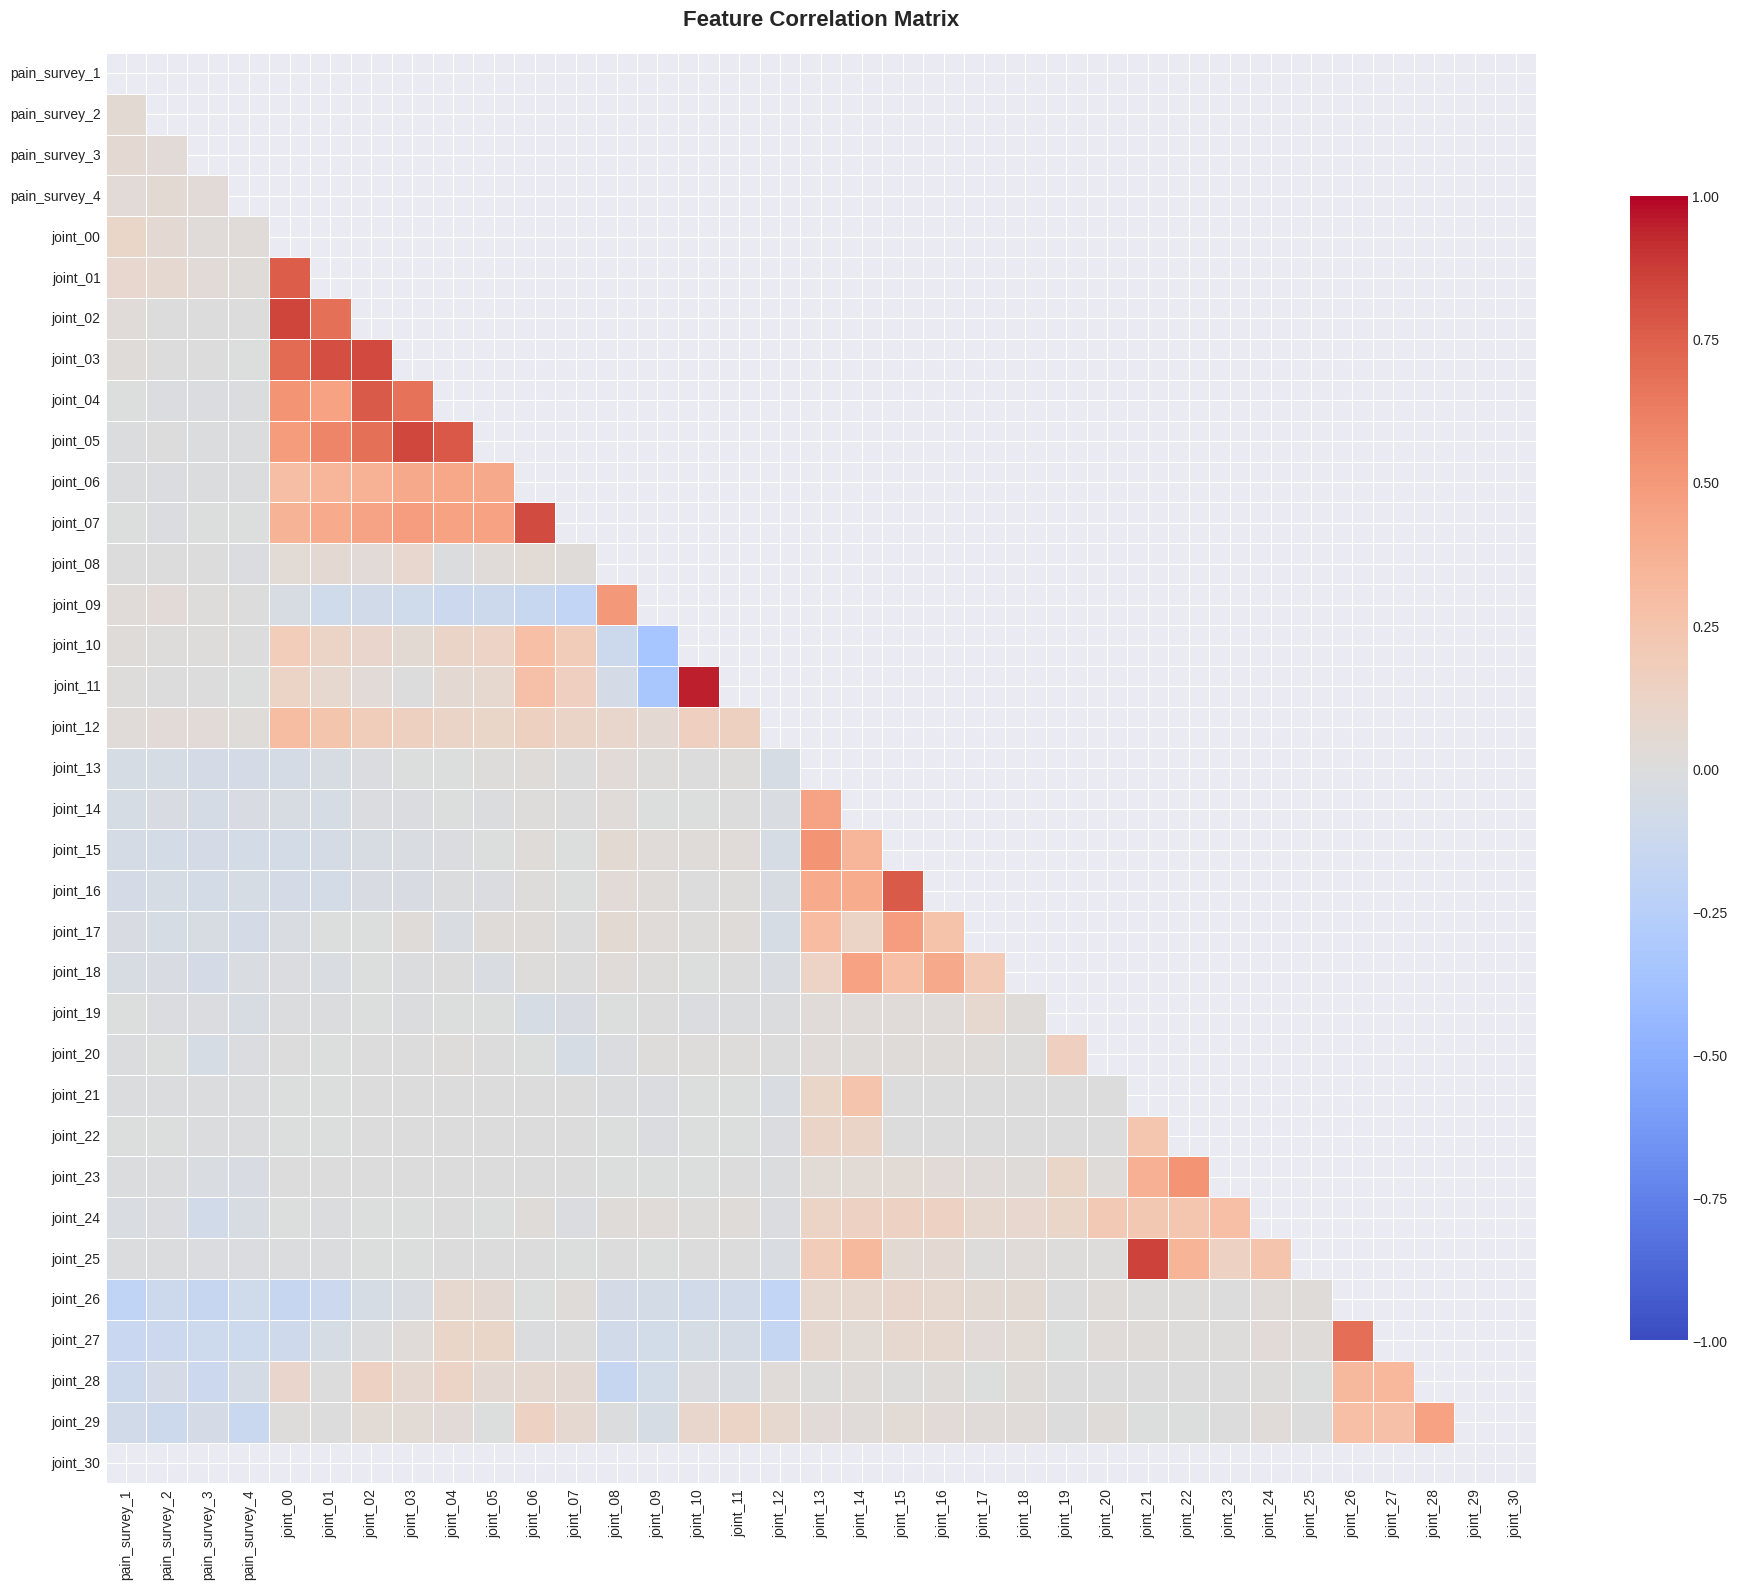


HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.95)
No highly correlated pairs found.


In [27]:
# Calculate correlation matrix
corr_matrix = X_train[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
threshold = 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("\n" + "="*80)
print(f"HIGHLY CORRELATED FEATURE PAIRS (|r| > {threshold})")
print("="*80)
if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"{feat1:15s} <-> {feat2:15s} : r = {corr:6.3f}")
    print(f"\n   → RECOMMENDATION: Consider combining or dropping one from each pair")
else:
    print("No highly correlated pairs found.")
print("="*80)

## 8. Sample Variability Analysis

**Question:** How much do samples vary within vs. between pain levels?

/tmp/ipykernel_176648/78829700.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=pain_labels_list[:len(sorted_labels)],
/tmp/ipykernel_176648/78829700.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=pain_labels_list[:len(sorted_labels)],
/tmp/ipykernel_176648/78829700.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=pain_labels_list[:len(sorted_labels)],
/tmp/ipykernel_176648/78829700.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

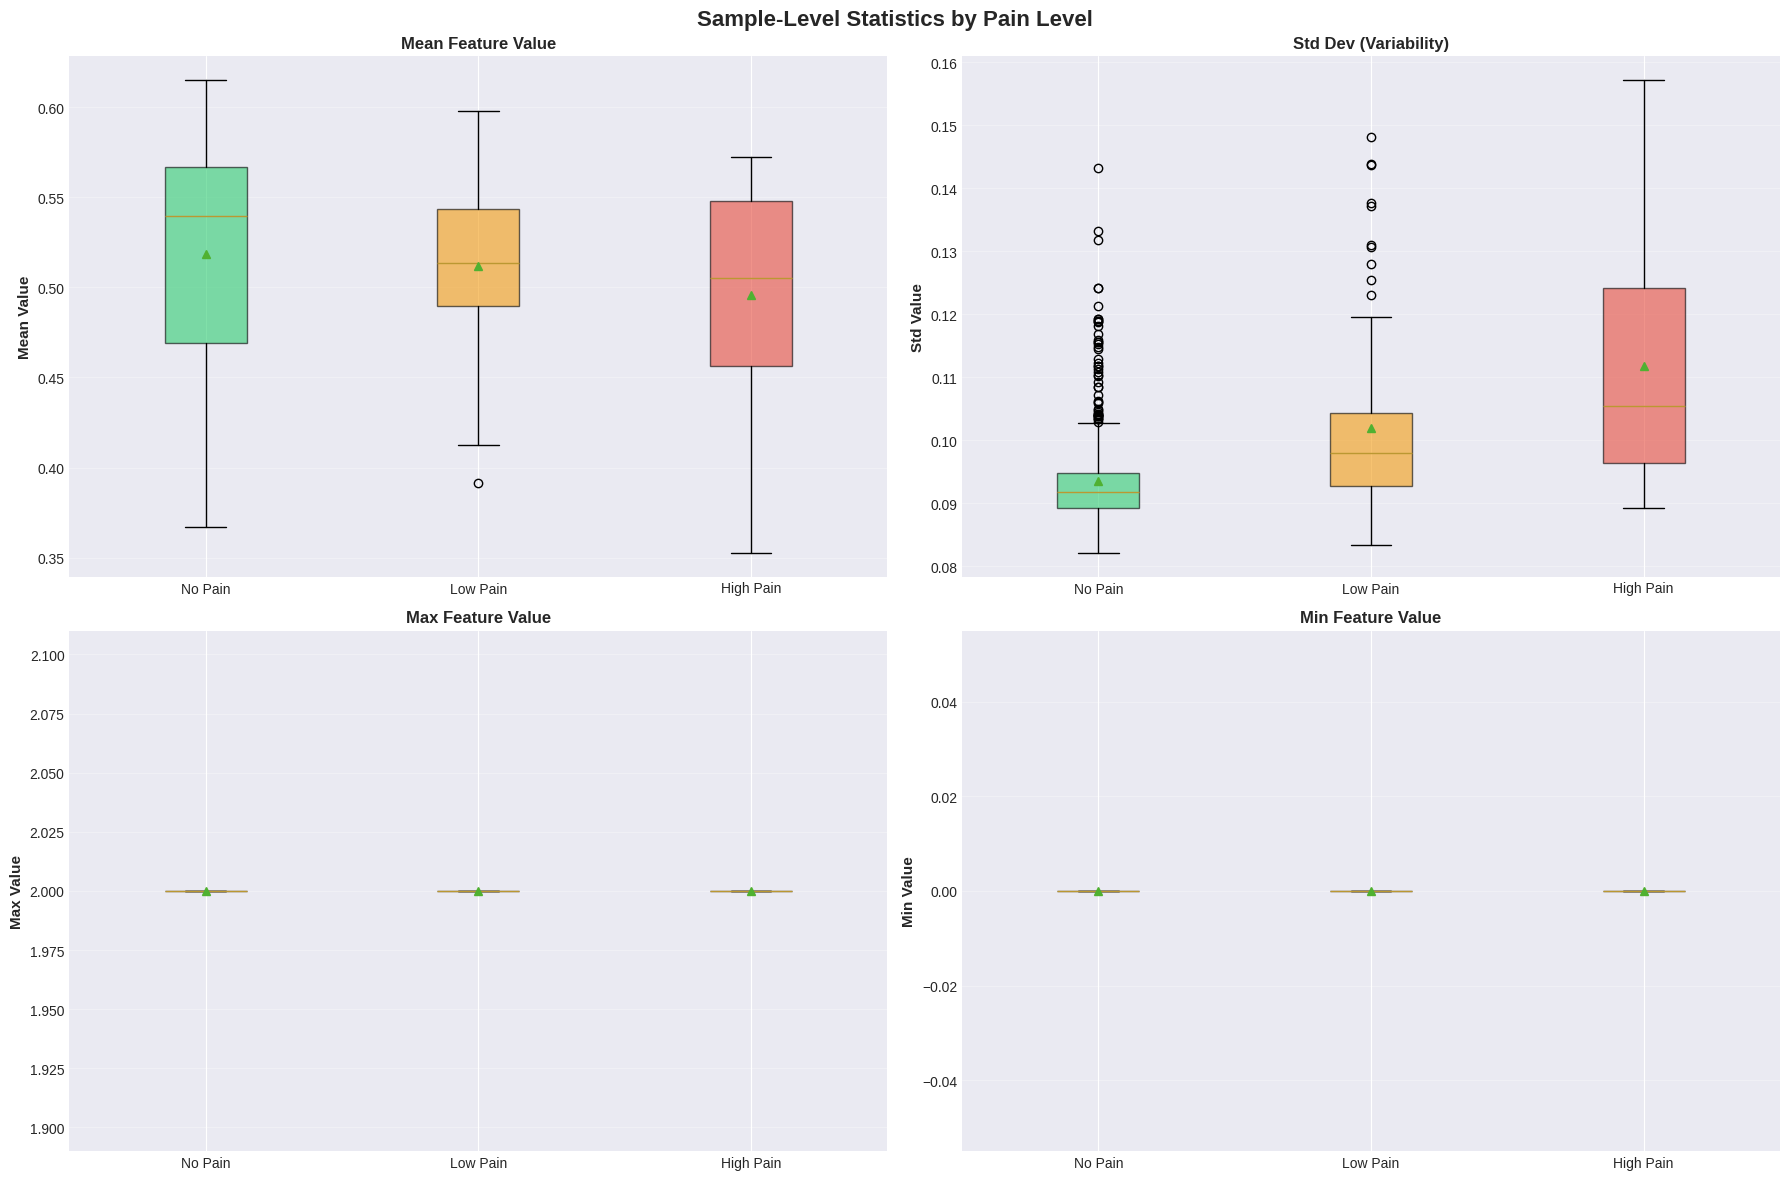


💡 INTERPRETATION:
  - Separated boxes = pain levels are distinguishable (good!)
  - Overlapping boxes = harder to classify
  - Large box height = high within-class variability


In [28]:
# Calculate per-sample statistics
sample_stats = []

for sample_id in df_merged['sample_index'].unique():
    sample_data = df_merged[df_merged['sample_index'] == sample_id]
    # Use the appropriate label column
    if 'label_int' in df_merged.columns:
        label = sample_data['label_int'].iloc[0]
    else:
        label = sample_data['label'].iloc[0]
    
    # Calculate statistics for this sample
    stats_dict = {
        'sample_id': sample_id,
        'label': label,
        'mean_value': sample_data[feature_cols].mean().mean(),
        'std_value': sample_data[feature_cols].std().mean(),
        'max_value': sample_data[feature_cols].max().max(),
        'min_value': sample_data[feature_cols].min().min(),
    }
    sample_stats.append(stats_dict)

sample_stats_df = pd.DataFrame(sample_stats)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics = ['mean_value', 'std_value', 'max_value', 'min_value']
titles = ['Mean Feature Value', 'Std Dev (Variability)', 'Max Feature Value', 'Min Feature Value']

# Define colors for box plots
colors = ['#2ecc71', '#f39c12', '#e74c3c']
pain_labels_list = ['No Pain', 'Low Pain', 'High Pain']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Create box plots for each pain level
    sorted_labels = sorted(sample_stats_df['label'].unique())
    data_by_class = [sample_stats_df[sample_stats_df['label'] == label][metric].values 
                     for label in sorted_labels]
    
    bp = ax.boxplot(data_by_class, labels=pain_labels_list[:len(sorted_labels)],
                    patch_artist=True, showmeans=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors[:len(sorted_labels)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Sample-Level Statistics by Pain Level', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("  - Separated boxes = pain levels are distinguishable (good!)")
print("  - Overlapping boxes = harder to classify")
print("  - Large box height = high within-class variability")

## 9. Sequence Window Analysis

**Critical for model design:**
- How many sequences are created with different window/stride settings?
- Trade-off: more sequences vs. data leakage


SEQUENCE WINDOWING ANALYSIS
            Configuration  Window  Stride  Seq/Sample  Total Seq  Overlap %   Risk
 No Overlap (Recommended)     160     160           1        661        0.0    Low
             Half Overlap     160      80           1        661       50.0 Medium
          Quarter Overlap     160      40           1        661       75.0   High
            Heavy Overlap     160      20           1        661       87.5   High
  Half Window, No Overlap      80      80           2       1322        0.0    Low
Half Window, Half Overlap      80      40           3       1983       50.0 Medium

💡 KEY INSIGHTS:
  - You have 661 unique samples (users)
  - Each sample has 160 timesteps

⚠️  OVERFITTING RISK:
  - HIGH overlap = sequences from same user in multiple batches
  - Model learns to recognize individual users, not pain patterns
  - Training accuracy ↑ but validation accuracy ↓

✅ RECOMMENDATION:
  - Use NO OVERLAP (stride = window = 160)
  - This gives 1 sequence per user

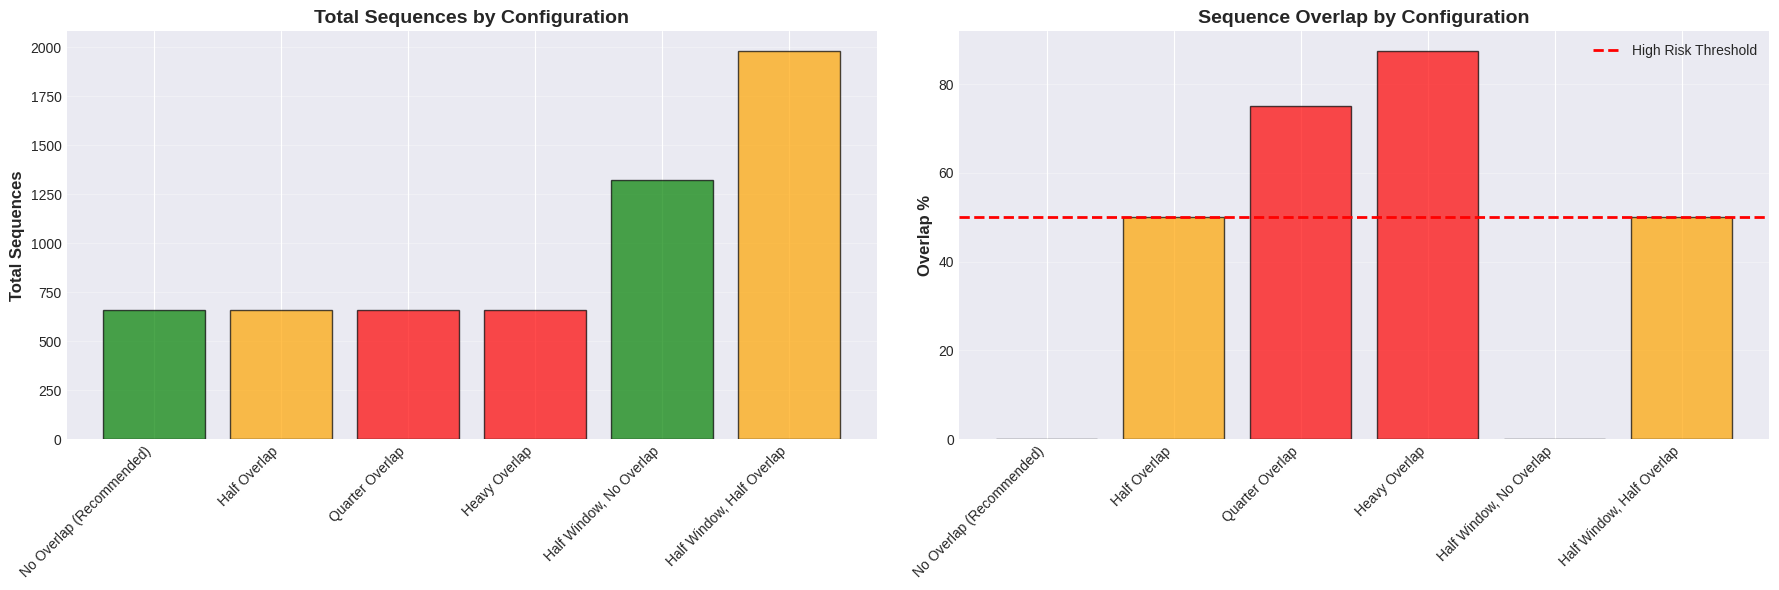

In [29]:
# Calculate sequences for different configurations
timesteps_per_sample = 160  # Each pirate has 160 timesteps
num_samples = X_train['sample_index'].nunique()

configs = [
    {'window': 160, 'stride': 160, 'name': 'No Overlap (Recommended)'},
    {'window': 160, 'stride': 80, 'name': 'Half Overlap'},
    {'window': 160, 'stride': 40, 'name': 'Quarter Overlap'},
    {'window': 160, 'stride': 20, 'name': 'Heavy Overlap'},
    {'window': 80, 'stride': 80, 'name': 'Half Window, No Overlap'},
    {'window': 80, 'stride': 40, 'name': 'Half Window, Half Overlap'},
]

results = []
for cfg in configs:
    window = cfg['window']
    stride = cfg['stride']
    
    # Calculate number of sequences per sample
    num_sequences_per_sample = max(1, (timesteps_per_sample - window) // stride + 1)
    total_sequences = num_samples * num_sequences_per_sample
    
    # Calculate overlap percentage
    if stride < window:
        overlap_pct = ((window - stride) / window) * 100
    else:
        overlap_pct = 0
    
    results.append({
        'Configuration': cfg['name'],
        'Window': window,
        'Stride': stride,
        'Seq/Sample': num_sequences_per_sample,
        'Total Seq': total_sequences,
        'Overlap %': overlap_pct,
        'Risk': 'High' if overlap_pct > 50 else ('Medium' if overlap_pct > 0 else 'Low')
    })

results_df = pd.DataFrame(results)

print("\n" + "="*100)
print("SEQUENCE WINDOWING ANALYSIS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

print("\n💡 KEY INSIGHTS:")
print(f"  - You have {num_samples} unique samples (users)")
print(f"  - Each sample has {timesteps_per_sample} timesteps")
print("\n⚠️  OVERFITTING RISK:")
print("  - HIGH overlap = sequences from same user in multiple batches")
print("  - Model learns to recognize individual users, not pain patterns")
print("  - Training accuracy ↑ but validation accuracy ↓")
print("\n✅ RECOMMENDATION:")
print("  - Use NO OVERLAP (stride = window = 160)")
print("  - This gives 1 sequence per user = clean train/val split")
print("  - Better generalization to new users")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot of total sequences
ax1.bar(range(len(results_df)), results_df['Total Seq'], 
        color=['green' if r == 'Low' else 'orange' if r == 'Medium' else 'red' 
               for r in results_df['Risk']],
        alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['Configuration'], rotation=45, ha='right')
ax1.set_ylabel('Total Sequences', fontsize=12, fontweight='bold')
ax1.set_title('Total Sequences by Configuration', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Bar plot of overlap percentage
ax2.bar(range(len(results_df)), results_df['Overlap %'],
        color=['green' if r == 'Low' else 'orange' if r == 'Medium' else 'red' 
               for r in results_df['Risk']],
        alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels(results_df['Configuration'], rotation=45, ha='right')
ax2.set_ylabel('Overlap %', fontsize=12, fontweight='bold')
ax2.set_title('Sequence Overlap by Configuration', fontsize=14, fontweight='bold')
ax2.axhline(y=50, color='red', linestyle='--', linewidth=2, label='High Risk Threshold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Training Recommendations Summary

Based on all analyses above, here are concrete recommendations for your model.

In [30]:
print("\n" + "="*100)
print("🎯 TRAINING RECOMMENDATIONS BASED ON DATA ANALYSIS")
print("="*100)

print("\n1. SEQUENCE CONFIGURATION:")
print("   ✅ window_size: 160 (full sample length)")
print("   ✅ stride: 160 (no overlap - prevents overfitting)")
print("   Why: Avoids data leakage between train/val splits")

print("\n2. CLASS IMBALANCE HANDLING:")
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"   ⚠️  Imbalance ratio: {imbalance_ratio:.2f}x")
print("   ✅ Use class weights in loss function")
print("   ✅ Enable oversampling with augmentation")
print("   ✅ Use F1 score (not accuracy) for evaluation")

print("\n3. DATA PREPROCESSING:")
if constant_features:
    print(f"   ✅ Drop constant features: {constant_features}")
if skewed_features:
    print(f"   ✅ Apply log transform to {len(skewed_features)} skewed features")
print("   ✅ Apply min-max normalization (features have different scales)")
if high_corr_pairs:
    print(f"   ✅ Consider combining {len(high_corr_pairs)} highly correlated feature pairs")

print("\n4. AUGMENTATION:")
print("   ✅ Enable augmentation (dataset is small)")
print("   ✅ Use noise + scaling + time shift")
print("   ✅ Moderate noise level (0.01) to create diversity")
print("   Why: Prevents overfitting to limited training samples")

print("\n5. MODEL ARCHITECTURE:")
print("   ✅ RNN type: LSTM or GRU (better for time series than vanilla RNN)")
print("   ✅ Bidirectional: True (captures both forward/backward patterns)")
print("   ✅ Hidden size: 64-128 (small dataset, avoid overparameterization)")
print("   ✅ Num layers: 1-2 (more = overfitting risk)")
print("   ✅ Dropout: 0.3-0.5 (regularization is critical)")

print("\n6. TRAINING STRATEGY:")
print("   ✅ Learning rate: 0.0005-0.001 (start conservative)")
print("   ✅ Batch size: 32-64 (dataset is small)")
print("   ✅ Early stopping: patience=50 (allow time to converge)")
print("   ✅ LR scheduler: ReduceLROnPlateau (adaptive learning)")
print("   ✅ Monitor: val_f1 (not val_loss, due to class imbalance)")

print("\n7. VALIDATION STRATEGY:")
print("   ✅ Use stratified split (maintain class balance)")
print("   ✅ Val size: 15-20% (small dataset, need enough for both)")
print("   ⚠️  Watch for: train_f1 >> val_f1 (overfitting indicator)")
print("   ⚠️  Watch for: val_loss increasing while train_loss decreases")

print("\n8. EXPECTED PERFORMANCE:")
print(f"   📊 Baseline (random): ~{100/len(class_counts):.1f}% accuracy")
print(f"   📊 Majority class: ~{class_counts.max()/len(y_train)*100:.1f}% accuracy")
print("   🎯 Target: 70-85% F1 score (realistic for small imbalanced dataset)")
print("   ⚠️  >90% train F1 + <70% val F1 = OVERFITTING!")

print("\n" + "="*100)
print("✅ RECOMMENDATION: Update your config with these settings and retrain!")
print("="*100)


🎯 TRAINING RECOMMENDATIONS BASED ON DATA ANALYSIS

1. SEQUENCE CONFIGURATION:
   ✅ window_size: 160 (full sample length)
   ✅ stride: 160 (no overlap - prevents overfitting)
   Why: Avoids data leakage between train/val splits

2. CLASS IMBALANCE HANDLING:
   ⚠️  Imbalance ratio: 9.12x
   ✅ Use class weights in loss function
   ✅ Enable oversampling with augmentation
   ✅ Use F1 score (not accuracy) for evaluation

3. DATA PREPROCESSING:
   ✅ Drop constant features: ['joint_30']
   ✅ Apply log transform to 13 skewed features
   ✅ Apply min-max normalization (features have different scales)

4. AUGMENTATION:
   ✅ Enable augmentation (dataset is small)
   ✅ Use noise + scaling + time shift
   ✅ Moderate noise level (0.01) to create diversity
   Why: Prevents overfitting to limited training samples

5. MODEL ARCHITECTURE:
   ✅ RNN type: LSTM or GRU (better for time series than vanilla RNN)
   ✅ Bidirectional: True (captures both forward/backward patterns)
   ✅ Hidden size: 64-128 (small 

## 11. Quick Config Generator

Copy and paste these optimal settings into your `default_config.yaml`:

In [31]:
optimal_config = f"""
# OPTIMIZED CONFIGURATION BASED ON DATA ANALYSIS
# Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

sequences:
  window_size: 160  # Full sample length
  stride: 160       # No overlap - prevents overfitting

augmentation:
  enabled: True
  oversample: True
  target_distribution: "balanced"
  augment_duplicates: True
  noise_level: 0.01      # Moderate noise for diversity
  scale_range: [0.95, 1.05]
  shift_range: 5
  apply_noise: True      # Enable noise
  apply_scaling: True
  apply_shift: True

model:
  rnn_type: "LSTM"       # Better than RNN for time series
  hidden_size: 128       # Moderate size
  num_layers: 2          # Don't go too deep
  bidirectional: True    # Capture both directions
  dropout_rate: 0.3      # Regularization

training:
  epochs: 500
  batch_size: 64
  learning_rate: 0.001   # Conservative start
  l2_lambda: 0.001       # Weight decay
  patience: 50           # Allow convergence
  evaluation_metric: "val_f1"  # F1 for imbalanced data
  mode: "max"
  
  scheduler:
    enabled: True
    type: "ReduceLROnPlateau"
    factor: 0.5
    patience: 10
    min_lr: 1.0e-6

dataloader:
  num_workers: 0         # Avoid multiprocessing issues
  shuffle_train: True
  drop_last: False
  pin_memory: False      # Auto-detected in notebook
"""

print(optimal_config)
print("\n💾 TIP: Copy this to your default_config.yaml file!")


# OPTIMIZED CONFIGURATION BASED ON DATA ANALYSIS
# Generated: 2025-11-11 10:38:17

sequences:
  window_size: 160  # Full sample length
  stride: 160       # No overlap - prevents overfitting

augmentation:
  enabled: True
  oversample: True
  target_distribution: "balanced"
  augment_duplicates: True
  noise_level: 0.01      # Moderate noise for diversity
  scale_range: [0.95, 1.05]
  shift_range: 5
  apply_noise: True      # Enable noise
  apply_scaling: True
  apply_shift: True

model:
  rnn_type: "LSTM"       # Better than RNN for time series
  hidden_size: 128       # Moderate size
  num_layers: 2          # Don't go too deep
  bidirectional: True    # Capture both directions
  dropout_rate: 0.3      # Regularization

training:
  epochs: 500
  batch_size: 64
  learning_rate: 0.001   # Conservative start
  l2_lambda: 0.001       # Weight decay
  patience: 50           # Allow convergence
  evaluation_metric: "val_f1"  # F1 for imbalanced data
  mode: "max"

  scheduler:
    enabled